# Exploratory Cancer Transcriptomics Analysis

This project explores gene expression differences between cancer subtypes using exploratory bioinformatics techniques in Python.

## Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
#read datasets
data = pd.read_csv("data.csv")
labels = pd.read_csv("labels.csv")

In [3]:
data.head()

,Unnamed: 0,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
4,sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


In [4]:
labels.head()

,Unnamed: 0,Class
0,sample_0,PRAD
1,sample_1,LUAD
2,sample_2,PRAD
3,sample_3,PRAD
4,sample_4,BRCA


In [5]:
data.columns[0]

'Unnamed: 0'

In [6]:
labels.columns[0]

'Unnamed: 0'

In [7]:
#merge datasets using sample IDs
merged_df = pd.merge(data,labels, on = "Unnamed: 0")
#change the name of the column
merged_df.rename(columns = {"Unnamed: 0": "Sample_ID"}, inplace = True)

In [8]:
merged_df.head()

,Sample_ID,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,Class
0,sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0,PRAD
1,sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0,LUAD
2,sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0,PRAD
3,sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,...,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0,PRAD
4,sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,...,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0,BRCA


In [9]:
merged_df.tail()

,Sample_ID,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530,Class
796,sample_796,0.0,1.865642,2.718197,7.350099,10.006003,0.0,6.764792,0.496922,0.0,...,9.118313,10.004852,4.484415,9.614701,12.031267,9.813063,10.092770,8.819269,0.000000,BRCA
797,sample_797,0.0,3.942955,4.453807,6.346597,10.056868,0.0,7.320331,0.000000,0.0,...,9.623335,9.823921,6.555327,9.064002,11.633422,10.317266,8.745983,9.659081,0.000000,LUAD
798,sample_798,0.0,3.249582,3.707492,8.185901,9.504082,0.0,7.536589,1.811101,0.0,...,8.610704,10.485517,3.589763,9.350636,12.180944,10.681194,9.466711,4.677458,0.586693,COAD
799,sample_799,0.0,2.590339,2.787976,7.318624,9.987136,0.0,9.213464,0.000000,0.0,...,8.605387,11.004677,4.745888,9.626383,11.198279,10.335513,10.400581,5.718751,0.000000,PRAD
800,sample_800,0.0,2.325242,3.805932,6.530246,9.560367,0.0,7.957027,0.000000,0.0,...,8.594354,10.243079,9.139459,10.102934,11.641081,10.607358,9.844794,4.550716,0.000000,PRAD


## Dataset Overview and Cleaning

The datasets were merged using sample IDs, and basic quality checks were performed to inspect dimensions, data types, and missing values.

In [10]:
#check the dataset dimensions
merged_df.shape

(801, 20533)

In [11]:
#display dataset information
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Columns: 20533 entries, Sample_ID to Class
dtypes: float64(20531), object(2)
memory usage: 125.5+ MB


In [12]:
#check missing values
merged_df.isnull().sum()

Sample_ID     0
gene_0        0
gene_1        0
gene_2        0
gene_3        0
             ..
gene_20527    0
gene_20528    0
gene_20529    0
gene_20530    0
Class         0
Length: 20533, dtype: int64

In [13]:
merged_df.isnull().sum().sum()

np.int64(0)

## Cancer Subtype Distribution

This section explores the distribution of cancer subtypes present in the dataset.

In [14]:
#count samples in each cancer type
merged_df["Class"].value_counts()

Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

- BRCA — Breast Invasive Carcinoma
- KIRC — Kidney Renal Clear Cell Carcinoma
- LUAD — Lung Adenocarcinoma
- PRAD — Prostate Adenocarcinoma
- COAD — Colon Adenocarcinoma

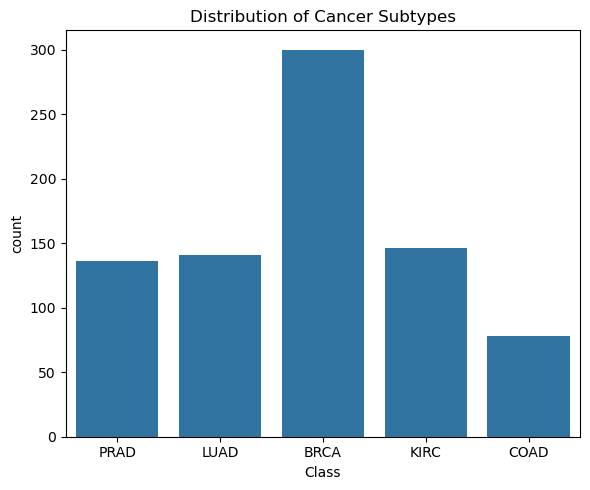

In [15]:
#set figure size
plt.figure(figsize = (6,5))

#plot cancer subtype distribution
sns.countplot(x = "Class", data = merged_df)

#add title
plt.title("Distribution of Cancer Subtypes")

#improve layout
plt.tight_layout()

plt.show()

In [16]:
#select only gene columns
gene_columns = merged_df.columns[1 : -1]
gene_columns

Index(['gene_0', 'gene_1', 'gene_2', 'gene_3', 'gene_4', 'gene_5', 'gene_6',
       'gene_7', 'gene_8', 'gene_9',
       ...
       'gene_20521', 'gene_20522', 'gene_20523', 'gene_20524', 'gene_20525',
       'gene_20526', 'gene_20527', 'gene_20528', 'gene_20529', 'gene_20530'],
      dtype='object', length=20531)

## Mean Gene Expression Analysis

Average expression values were calculated to identify highly expressed genes across the dataset.

In [17]:
#calculate the mean expression of all genes
mean_expression = merged_df[gene_columns].mean()
mean_expression.head()

gene_0    0.026642
gene_1    3.010909
gene_2    3.095350
gene_3    6.722305
gene_4    9.813612
dtype: float64

In [18]:
#sort genes by mean expression
top_genes = mean_expression.sort_values(ascending = False)
top_genes.head()

gene_230      16.430442
gene_5380     16.381964
gene_232      15.967993
gene_18570    15.777747
gene_6857     15.714588
dtype: float64

In [19]:
#select top 10 expressed genes
top10 = top_genes.head(10)
top10

gene_230      16.430442
gene_5380     16.381964
gene_232      15.967993
gene_18570    15.777747
gene_6857     15.714588
gene_5388     15.658668
gene_1322     15.489623
gene_6698     15.356662
gene_15242    15.161160
gene_3371     15.069407
dtype: float64

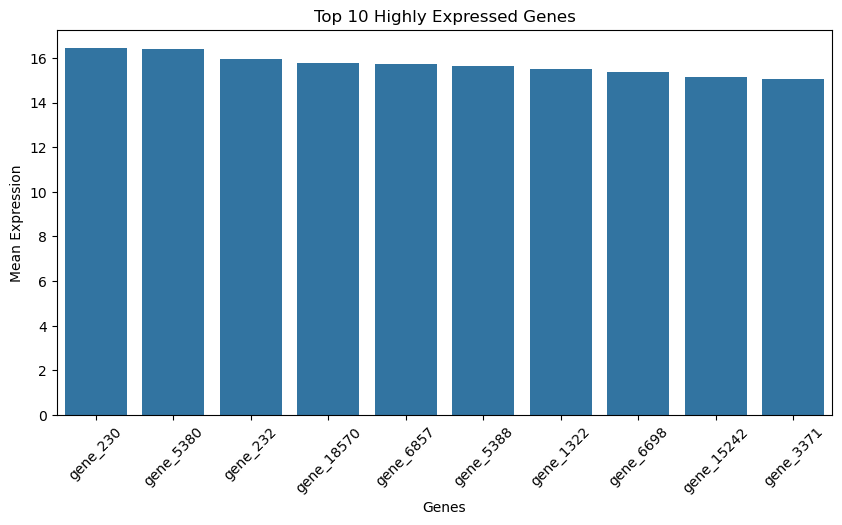

In [20]:
#plot top expressed genes
plt.figure(figsize=(10,5))

sns.barplot(
    x = top10.index,
    y = top10.values
)

plt.xticks(rotation = 45)

plt.title("Top 10 Highly Expressed Genes")

plt.xlabel("Genes")

plt.ylabel("Mean Expression")

plt.show()


In [21]:
merged_df.groupby("Class")[gene_columns].mean()

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
Class,,,,,,,,,,,,,,,,,,,,,
BRCA,0.011362,2.839739,2.805759,6.692613,10.003743,0.0,7.503838,0.499902,0.021714,0.031654,...,5.891983,9.004483,10.090170,6.214461,9.728951,11.748519,10.135163,9.774321,6.206215,0.073071
COAD,0.022212,3.438381,3.238618,7.830324,9.933747,0.0,7.292393,0.509116,0.000000,0.000000,...,5.473999,8.679328,9.966375,0.695664,9.121327,12.215350,10.294870,9.352634,3.616018,0.039924
KIRC,0.046544,2.398129,2.447997,6.340925,9.446830,0.0,7.008021,0.645374,0.024824,0.000000,...,6.431149,8.573289,10.037905,3.324251,10.072278,11.805309,10.204060,9.431097,5.099268,0.133671
LUAD,0.041088,3.358260,3.457701,6.625187,9.781486,0.0,7.283121,0.393179,0.015985,0.000000,...,5.557246,8.536567,9.966566,4.767049,9.675499,11.788373,9.962015,9.394807,5.277331,0.191586
PRAD,0.026544,3.441041,3.971262,6.662433,9.752363,0.0,7.807088,0.448975,0.007497,0.009264,...,5.926976,8.733751,10.145661,5.933344,9.841068,11.341440,10.267547,9.696780,5.849697,0.035729


## Differential Expression Analysis: BRCA vs LUAD

BRCA and LUAD samples were compared to investigate subtype-specific expression differences between genes.

In [22]:
#select BRCA samples
brca_df = merged_df[merged_df["Class"] == "BRCA"]

#select LUAD samples
luad_df = merged_df[merged_df["Class"] == "LUAD"]

In [23]:
#check number of samples in each group
print("BRCA samples", brca_df.shape[0])
print("LUAD samples", luad_df.shape[0])

BRCA samples 300
LUAD samples 141


In [24]:
#calculate average expression of each gene in BRCA samples
brca_mean = brca_df[gene_columns].mean()

#calculate average expression of each gene in LUAD samples
luad_mean = luad_df[gene_columns].mean()


In [25]:
brca_mean.head()

gene_0     0.011362
gene_1     2.839739
gene_2     2.805759
gene_3     6.692613
gene_4    10.003743
dtype: float64

In [26]:
luad_mean.head()

gene_0    0.041088
gene_1    3.358260
gene_2    3.457701
gene_3    6.625187
gene_4    9.781486
dtype: float64

In [27]:
#crate a comparison table for BRCA and LUAD mean expression
comparison_df = pd.DataFrame({
    "BRCA_mean": brca_mean,
    "LUAD_mean": luad_mean
})

comparison_df.head()

,BRCA_mean,LUAD_mean
gene_0,0.011362,0.041088
gene_1,2.839739,3.358260
gene_2,2.805759,3.457701
gene_3,6.692613,6.625187
gene_4,10.003743,9.781486


## Fold Change Analysis

Expression differences between BRCA and LUAD samples were calculated to identify potentially upregulated genes.

In [28]:
# calculate expression difference between BRCA and LUAD
comparison_df["Difference"] = (
    comparison_df["BRCA_mean"] - comparison_df["LUAD_mean"]
)

comparison_df.head()

,BRCA_mean,LUAD_mean,Difference
gene_0,0.011362,0.041088,-0.029727
gene_1,2.839739,3.358260,-0.518520
gene_2,2.805759,3.457701,-0.651942
gene_3,6.692613,6.625187,0.067426
gene_4,10.003743,9.781486,0.222257


In [29]:
# sort genes by expression difference
sorted_diff = comparison_df.sort_values(
    by = "Difference",
    ascending = False
)

sorted_diff.head(10)

,BRCA_mean,LUAD_mean,Difference
gene_15589,9.861198,0.110857,9.750341
gene_15586,7.576813,0.266853,7.309960
gene_706,7.111087,0.018140,7.092947
gene_17905,7.822391,0.874683,6.947708
gene_9652,9.887516,3.043928,6.843588
gene_6876,12.769879,6.162650,6.607229
gene_357,6.756417,0.233812,6.522605
gene_6530,6.850835,0.707191,6.143645
gene_11358,7.356861,1.433931,5.922930
gene_2248,7.004604,1.185828,5.818776


In [30]:
#genes highly expressed in LUAD 
sorted_diff.tail(10)

,BRCA_mean,LUAD_mean,Difference
gene_15591,0.512768,9.693965,-9.181196
gene_4422,1.073884,10.450262,-9.376378
gene_15894,0.639282,10.492451,-9.853169
gene_15899,0.201870,10.385622,-10.183752
gene_15895,0.085455,10.454468,-10.369013
gene_11903,0.194680,10.873975,-10.679295
gene_15897,2.899252,13.639469,-10.740217
gene_11550,2.409878,13.533082,-11.123204
gene_15896,0.294743,12.465032,-12.170290
gene_15898,1.067688,15.700952,-14.633264


In [31]:
#select top upregulated genes
top_upregulated = sorted_diff.head(10)

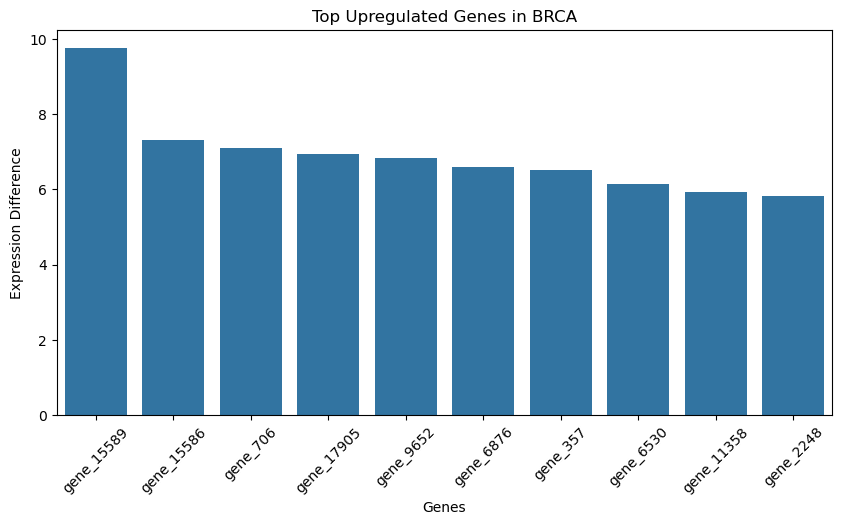

In [32]:
#plot top upregulated genes
plt.figure(figsize = (10,5))

sns.barplot(
    x = top_upregulated.index,
    y = top_upregulated["Difference"]
)

plt.xticks(rotation = 45)

plt.title("Top Upregulated Genes in BRCA")

plt.ylabel("Expression Difference")

plt.xlabel("Genes")

plt.show()

## Top Upregulated Genes in BRCA

The genes shown above have higher average expression levels in BRCA samples compared to LUAD samples.

This suggests that these genes may be more active in breast cancer tissue and could reflect biological differences between the two cancer types.

In [33]:
#select top 20 genes that are more highly expressed in BRCA
top20_genes = sorted_diff.head(20).index
top20_genes

Index(['gene_15589', 'gene_15586', 'gene_706', 'gene_17905', 'gene_9652',
       'gene_6876', 'gene_357', 'gene_6530', 'gene_11358', 'gene_2248',
       'gene_83', 'gene_14092', 'gene_13462', 'gene_6976', 'gene_1317',
       'gene_4160', 'gene_15789', 'gene_17993', 'gene_9225', 'gene_4599'],
      dtype='object')

In [34]:
#keep only BRCA and LUAD samples
heatmap_df = merged_df[
    merged_df["Class"].isin(["BRCA", "LUAD"])
]

heatmap_df.shape

(441, 20533)

In [35]:
#keep only top 20 selected genes
heatmap_data = heatmap_df[top20_genes]
heatmap_data.head()

,gene_15589,gene_15586,gene_706,gene_17905,gene_9652,gene_6876,gene_357,gene_6530,gene_11358,gene_2248,gene_83,gene_14092,gene_13462,gene_6976,gene_1317,gene_4160,gene_15789,gene_17993,gene_9225,gene_4599
1,0.000000,0.000000,0.000000,0.000000,1.465034,6.484409,0.000000,0.587845,0.587845,0.000000,2.176738,3.841047,6.014262,3.938935,9.328430,0.000000,0.000000,0.000000,0.587845,0.000000
4,14.975920,13.501464,10.190096,12.010059,10.828644,13.636772,3.208502,7.093793,8.953131,7.954388,10.337165,14.189315,12.416758,14.437967,12.912019,7.026180,7.260873,1.831269,11.712763,9.412070
8,0.352307,0.000000,0.000000,7.579829,6.824131,11.602439,2.707635,4.599109,0.871765,0.352307,0.352307,12.501949,5.878105,5.427841,6.382569,0.635336,0.635336,1.074848,8.697343,1.074848
10,14.123669,10.606498,9.681177,11.675895,10.385916,13.576083,10.248378,3.321423,6.649466,11.553749,11.120879,12.365680,10.338491,14.487080,15.171912,6.580103,6.828708,6.661721,12.534884,7.012267
13,0.000000,1.805746,0.873420,0.501821,10.042713,15.077383,8.486932,11.345372,6.042176,6.261437,1.805746,11.822905,5.826452,11.823073,12.287790,5.534367,10.109974,6.352391,2.479282,2.856030


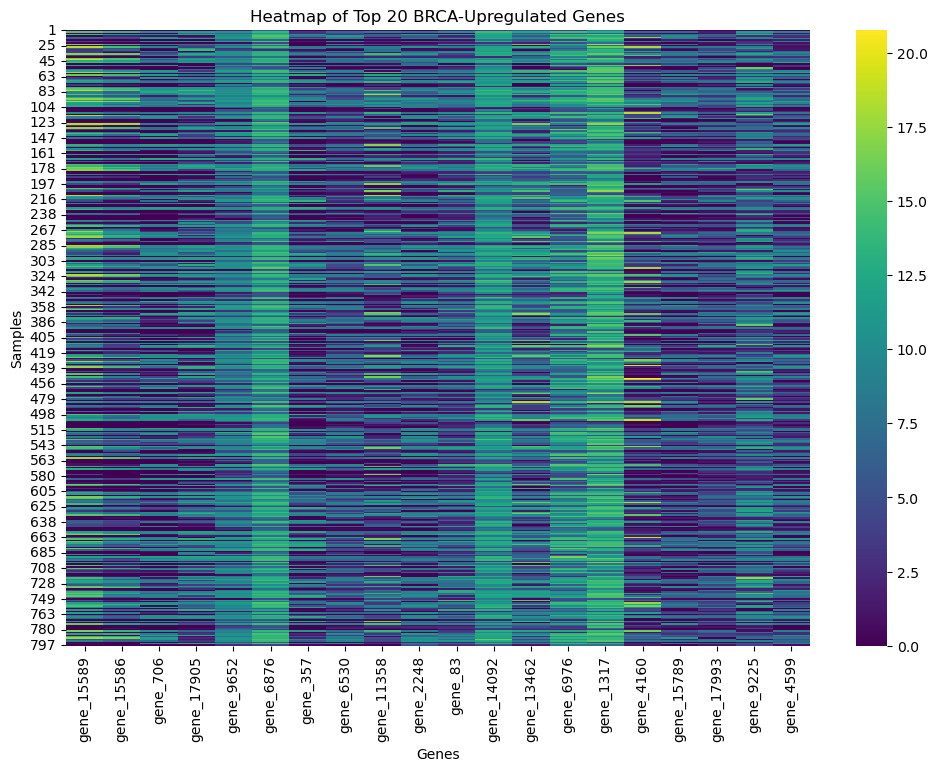

In [36]:
#create a heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    cmap = "viridis"
)

plt.title("Heatmap of Top 20 BRCA-Upregulated Genes")

plt.xlabel("Genes")
plt.ylabel("Samples")

plt.show()

### Heatmap of Top BRCA_Upregulated Genes

This heatmap shows the expression patterns of the top 20 genes that have higher average expression in BRCA compared to LUAD.

Brighter colors represent higher expression levels, while darker colors represent lower expression levels. This visualization helps observe whether the selected genes show consistent expression patterns across BRCA and LUAD samples.

## Correlation Analysis

Correlation analysis was performed to examine relationships between highly differential genes.

In [37]:
#calculate correlation between top genes
correlation_matrix = heatmap_data.corr()

correlation_matrix.head()

,gene_15589,gene_15586,gene_706,gene_17905,gene_9652,gene_6876,gene_357,gene_6530,gene_11358,gene_2248,gene_83,gene_14092,gene_13462,gene_6976,gene_1317,gene_4160,gene_15789,gene_17993,gene_9225,gene_4599
gene_15589,1.000000,0.967046,0.720605,0.683887,0.725192,0.747014,0.614938,0.691523,0.662334,0.748831,0.728594,0.682532,0.651311,0.576383,0.654928,0.453871,0.696446,0.674357,0.516597,0.683140
gene_15586,0.967046,1.000000,0.679202,0.627780,0.674926,0.692640,0.565454,0.667721,0.591401,0.722190,0.666510,0.642851,0.605370,0.552454,0.607244,0.433342,0.678969,0.616477,0.470721,0.632477
gene_706,0.720605,0.679202,1.000000,0.692413,0.748272,0.798112,0.598212,0.753692,0.564550,0.720101,0.755423,0.716547,0.699467,0.710702,0.645103,0.557782,0.769780,0.648593,0.363684,0.747629
gene_17905,0.683887,0.627780,0.692413,1.000000,0.648669,0.668143,0.552009,0.593957,0.644402,0.585034,0.669705,0.658776,0.607681,0.555900,0.570819,0.318029,0.590372,0.645285,0.516806,0.728957
gene_9652,0.725192,0.674926,0.748272,0.648669,1.000000,0.861968,0.647312,0.810031,0.543220,0.725331,0.701411,0.786992,0.591359,0.714866,0.669173,0.559101,0.736009,0.710901,0.481869,0.689471


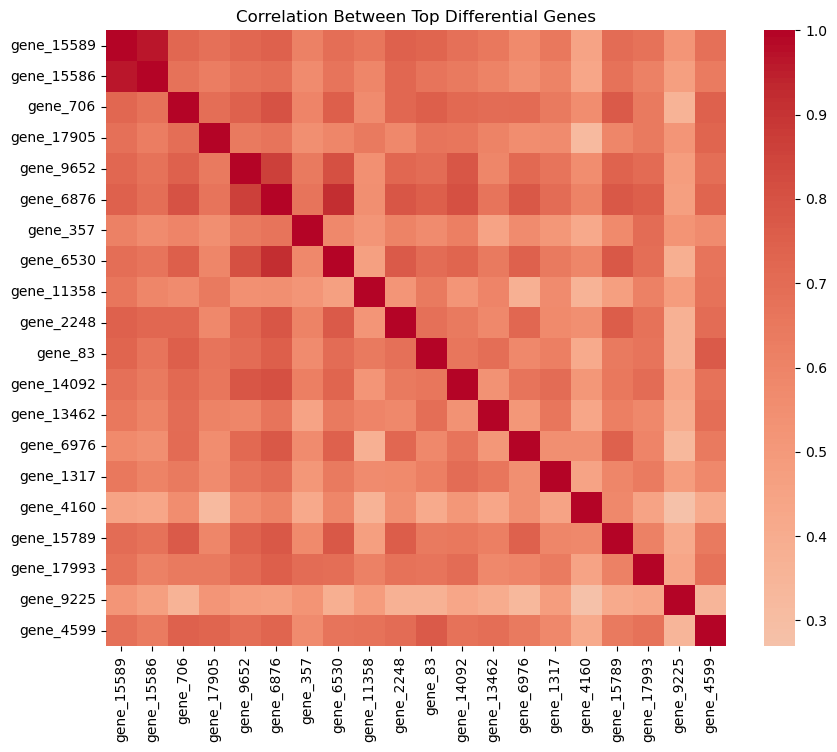

In [38]:
#plot correlation heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    cmap = "coolwarm",
    center = 0
)

plt.title("Correlation Between Top Differential Genes")

plt.show()

## Clustering Analysis

Hierarchical clustering was used to group samples and genes based on similar expression patterns.

In [39]:
#create color labels for cancer types
sample_colors = heatmap_df["Class"].map({
    "BRCA": "pink",
    "LUAD": "blue"
})

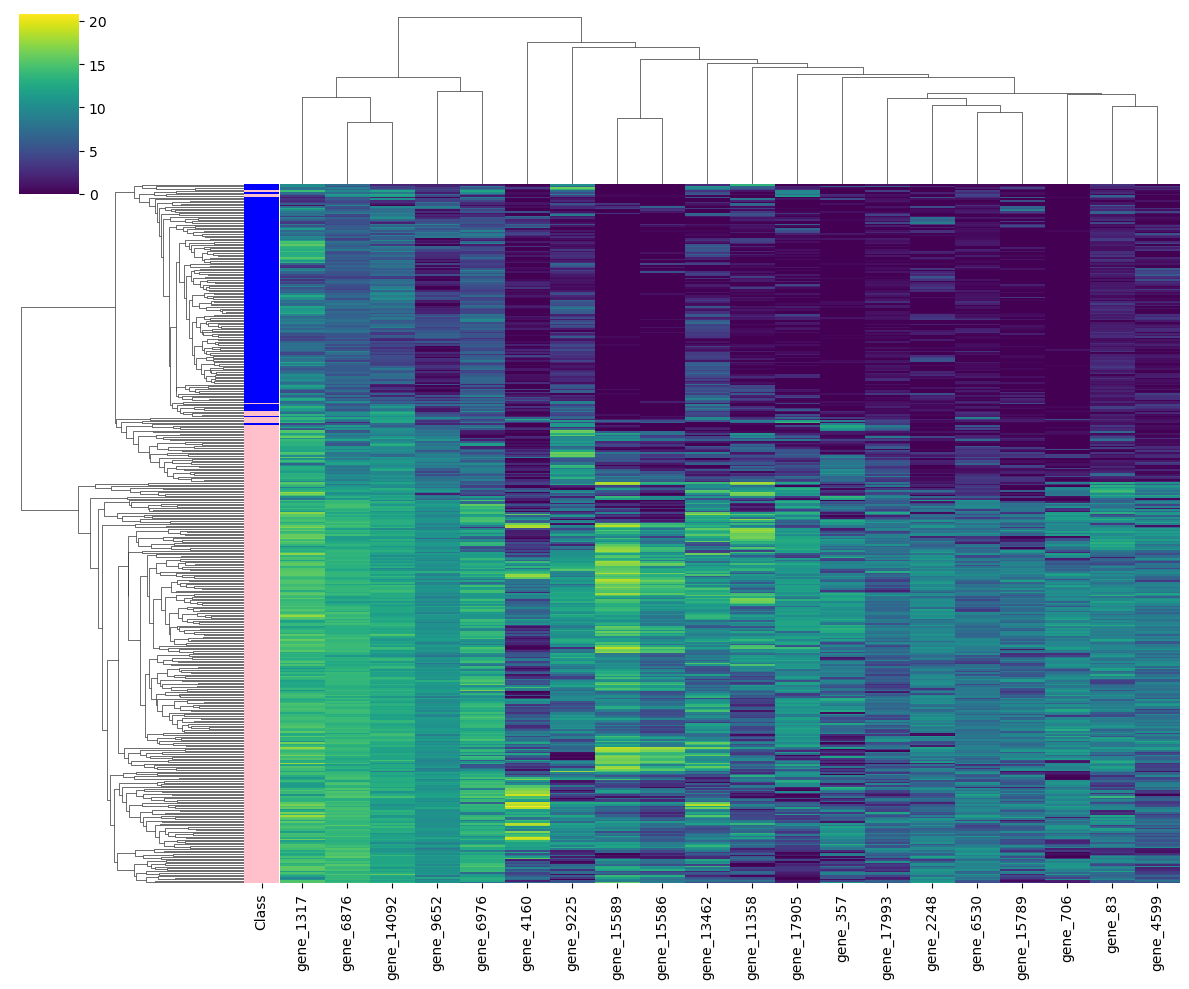

In [40]:
#create clustered heatmap
sns.clustermap(
    heatmap_data,
    cmap = "viridis",
    row_colors = sample_colors,
    figsize = (12,10),
    yticklabels = False
)

plt.show()

## PCA Analysis

PCA was applied to reduce the high dimensional expression data into two components for visualization.

In [41]:
 #select only BRCA and LUAD samples for PCA
pca_df = merged_df[merged_df["Class"].isin(["BRCA", "LUAD"])]

#select gene expression values only
X = pca_df[gene_columns]

#select cancer subtype labels
y = pca_df["Class"]

In [42]:
from sklearn.preprocessing import StandardScaler

#standardize gene expression values
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [43]:
from sklearn.decomposition import PCA

#reduce gene expression data into 2 principal components
pca = PCA(n_components = 2)

pca_result = pca.fit_transform(X_scaled)

In [44]:
#create a dataframe for pca results
pca_result_df = pd.DataFrame(
    data = pca_result,
    columns = ["PC1", "PC2"]
)

#add cancer subtype labels
pca_result_df["Class"] = y.values

pca_result_df.head()

,PC1,PC2,Class
0,-43.209501,36.823459,LUAD
1,43.880448,-28.585943,BRCA
2,39.783593,45.535422,BRCA
3,9.129445,-36.813829,BRCA
4,-82.864668,-117.679794,BRCA


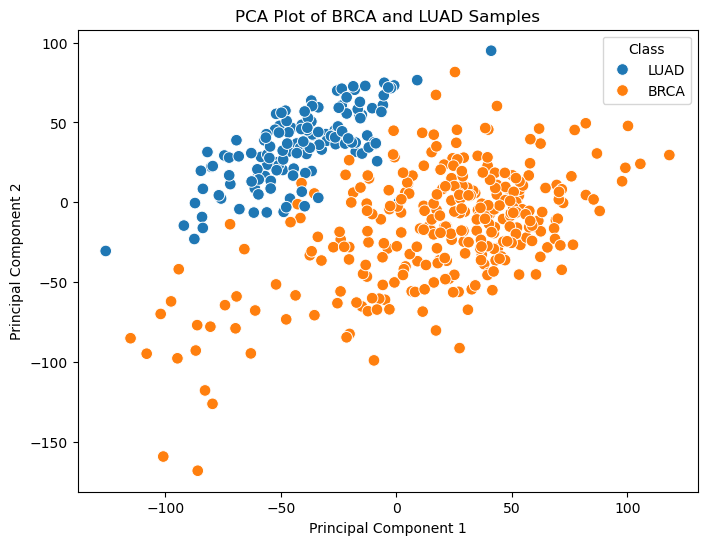

In [45]:
#plot PCA results
plt.figure(figsize=(8,6))

sns.scatterplot(
    data = pca_result_df,
    x="PC1",
    y="PC2",
    hue="Class",
    s=70
)

plt.title("PCA Plot of BRCA and LUAD Samples")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

The PCA plot shows partial separation between BRCA and LUAD samples based on their overall gene expression profiles.

LUAD samples appear to form a more compact cluster, while BRCA samples show greater variability across the principal components. This may suggest differences in transcriptional heterogeneity between the two cancer subtypes.

Although some overlap exists, the observed separation indicates that BRCA and LUAD possess distinct expression patterns.

## Variance Analysis

Variance analysis was used to identify genes with highly variable expression across samples.

In [46]:
#calculate variance of each gene
gene_variance = merged_df[gene_columns].var()

gene_variance.head()

gene_0    0.018728
gene_1    1.441987
gene_2    1.135506
gene_3    0.408089
gene_4    0.256580
dtype: float64

In [47]:
#sort genes by variance
sorted_variance = gene_variance.sort_values(
    ascending = False
)

sorted_variance.head(20)

gene_9176     44.763849
gene_9175     36.361940
gene_15898    34.503915
gene_15301    33.458776
gene_15589    31.325845
gene_3540     30.587696
gene_19661    30.080478
gene_3541     28.721689
gene_11250    26.515887
gene_15897    26.019446
gene_439      24.907236
gene_8014     24.536552
gene_15896    23.948239
gene_4773     23.585390
gene_19236    22.273271
gene_16283    22.219048
gene_9177     22.175862
gene_3461     22.165311
gene_8891     21.995722
gene_2844     21.633754
dtype: float64

In [48]:
#create variance dataframw
variance_df = pd.DataFrame({
    "Gene": sorted_variance.index,
    "Variance": sorted_variance.values
})

variance_df.head(10)

,Gene,Variance
0,gene_9176,44.763849
1,gene_9175,36.361940
2,gene_15898,34.503915
3,gene_15301,33.458776
4,gene_15589,31.325845
5,gene_3540,30.587696
6,gene_19661,30.080478
7,gene_3541,28.721689
8,gene_11250,26.515887
9,gene_15897,26.019446


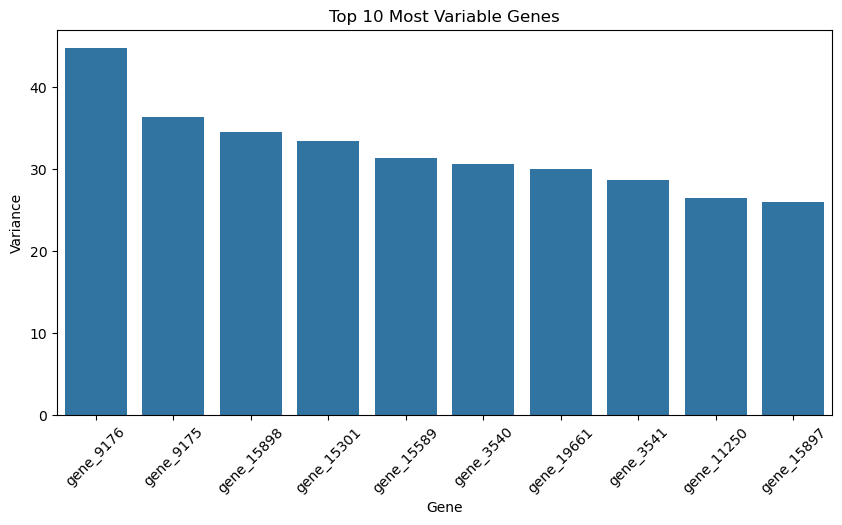

In [49]:
#select top variable genes
top_variable = variance_df.head(10)

#plot variance 
plt.figure(figsize=(10,5))

sns.barplot(
    data = top_variable,
    x = "Gene",
    y = "Variance"
)

plt.xticks(rotation = 45)
plt.title("Top 10 Most Variable Genes")
plt.show()

## Volcano Plot Analysis

A volcano plot was generated to visualize genes with strong expression differences between BRCA and LUAD samples.

In [50]:
#import statistical test
from scipy.stats import ttest_ind

In [51]:
#create empty list for p-values
p_values = []

#calculate p-value for each gene
for gene in gene_columns:

    brca_values = brca_df[gene]
    luad_values = luad_df[gene]

    #perform an independent t-test between BRCA and LUAD
    stat,p = ttest_ind(brca_values, luad_values)

    #store the p-value
    p_values.append(p)

    

In [52]:
#add p-values to the comparison dataframe
comparison_df["p_value"] = p_values

comparison_df.head()

,BRCA_mean,LUAD_mean,Difference,p_value
gene_0,0.011362,0.041088,-0.029727,2.187932e-02
gene_1,2.839739,3.358260,-0.518520,2.436979e-05
gene_2,2.805759,3.457701,-0.651942,3.692597e-10
gene_3,6.692613,6.625187,0.067426,2.413284e-01
gene_4,10.003743,9.781486,0.222257,1.578838e-05


In [53]:
# Calculate negative log10 p-values
comparison_df["neg_log10_p"] = -np.log10(
    comparison_df["p_value"]
)

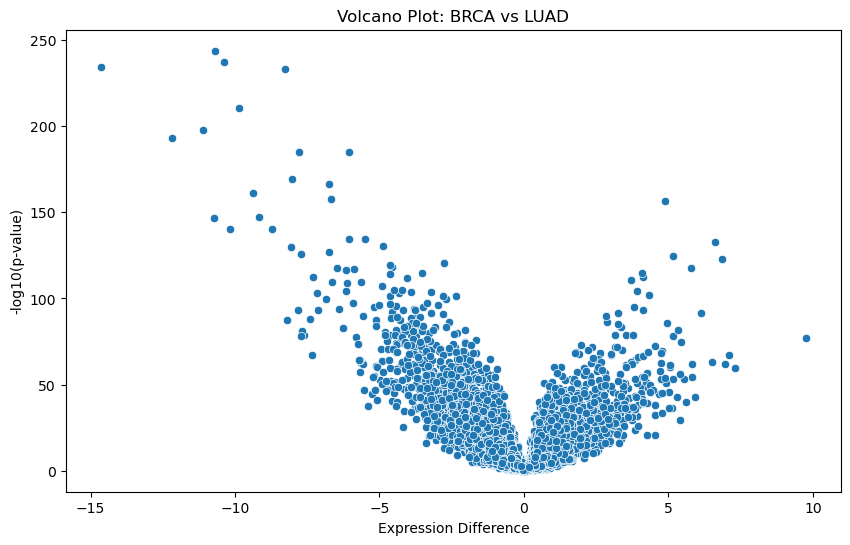

In [54]:
# Create volcano plot
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=comparison_df,
    x="Difference",
    y="neg_log10_p"
)

plt.title("Volcano Plot: BRCA vs LUAD")

plt.xlabel("Expression Difference")

plt.ylabel("-log10(p-value)")

plt.show()

# Conclusion

This project explored transcriptomic differences between BRCA and LUAD samples using exploratory bioinformatics techniques.

Heatmaps, clustering, PCA, and volcano plots suggested that the two cancer types exhibit distinct gene expression patterns.

In [55]:
# Save differential expression results
comparison_df.to_csv(
    "BRCA_vs_LUAD_results.csv",
    index=True
)